# OpenCV를 활용한 영상정보 전처리(6)

# 마스킹(Masking)

### 이미지 크기와 동일한 Mask를 만들고, 이미지에 Mask를 적용 시켜보자.

In [1]:
# 필요한 모듀 읽어오기

import cv2
from google.colab.patches import cv2_imshow
import numpy as np

In [ ]:
# OpenCV 버전을 확인합니다

print("OpenCV version:")
print(cv2.__version__)

OpenCV version:
4.6.0


In [2]:
# 내 구글 드라이버에 연동

from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


(496, 819, 3)


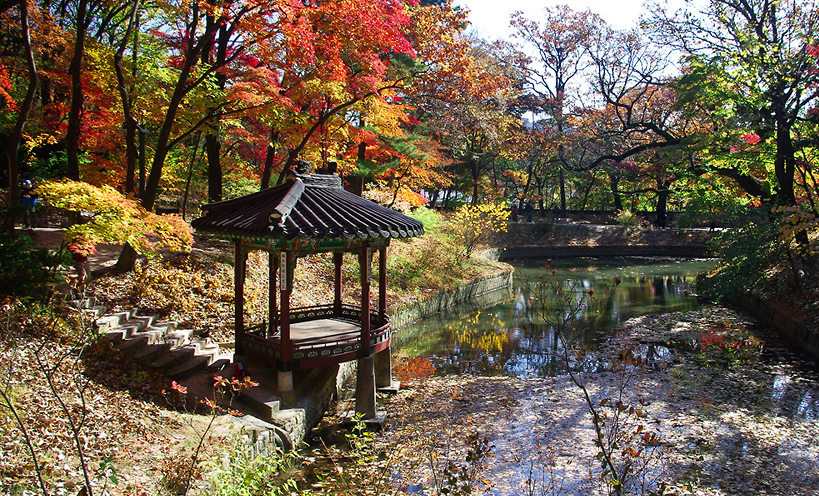

In [5]:
# 이미지를 읽어 온다.

img = cv2.imread('gdrive/My Drive/CV/Basic Vision Skills/images/rear_garden.PNG', cv2.IMREAD_COLOR)
print(img.shape)      # 형상 - (496, 819, 3)
cv2_imshow(img)       # 원본 이미지 출력

In [6]:
# 이미지의 높이와 넓이를 가져온다.
(height, width) = img.shape[:2]
print("width: {} pixels".format(width))      # 넓이 - width: 819 pixels
print("height: {} pixels".format(height))    # 높이 - height: 496 pixels

# 이미지의 중심을 구한다.
center = (width // 2, height // 2)
print("center: {} ".format(center))         # 이미지 중심 -  center: (409, 248)

width: 819 pixels
height: 496 pixels
center: (409, 248) 


In [9]:
# 이미지 크기와 동일한 mask를 만듭니다.
mask = np.zeros(img.shape[:2], dtype = "uint8")
print(" mask 형상 : {} ".format(mask.shape))      # mask 형상 - (496, 819)
print(mask[:5, :5])                               #

 mask 형상 : (496, 819) 
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [10]:
# mask 에 filter 시킬 모양(흰색 원)을 그립니다.
# - 반지름 300인 흰색 원 그리기

cv2.circle(mask, center, 300, (255, 255, 255), -1)    # 그림을 그릴 영상, 중심점, 반지름, 색상, -1은 도형전체를 채움

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

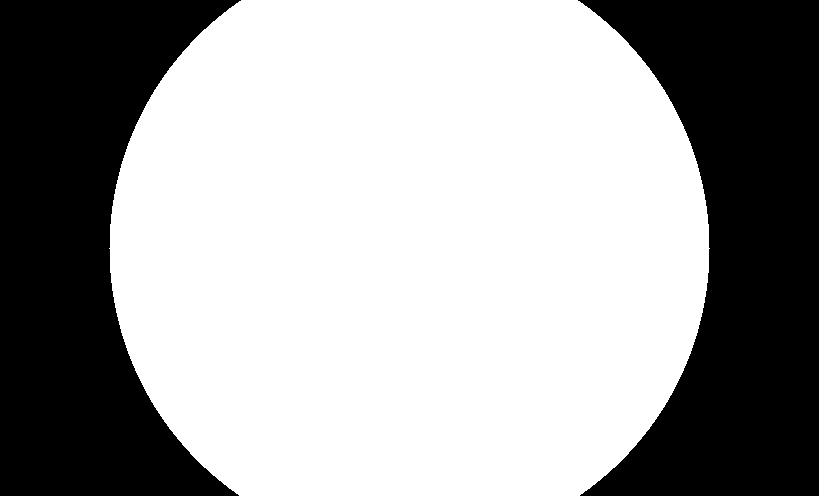

In [ ]:
# mask를 출력 한다.
cv2_imshow(mask)

(496, 819, 3)


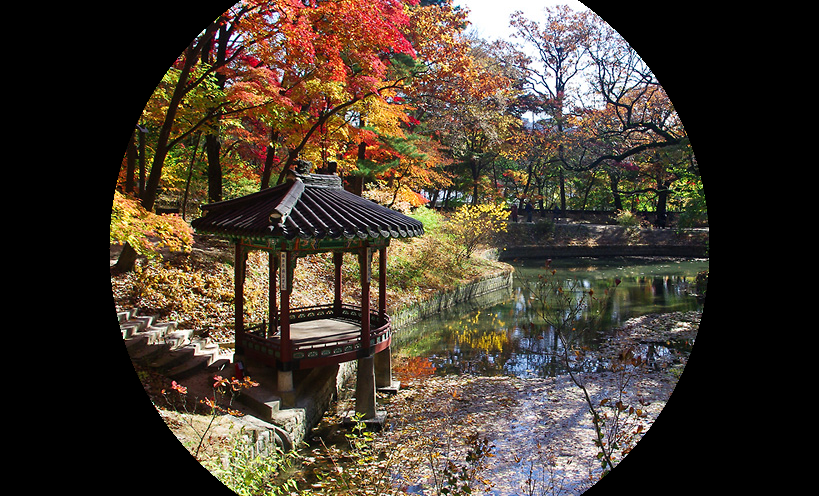

In [11]:
#  cv2.bitwise_and() 함수를 이용해 이미지에 mask를 적용한다.

masked = cv2.bitwise_and(img, img, mask = mask)
print(masked.shape)                               # 형상 - (496, 819, 3)
cv2_imshow(masked)                                # 마스크된 이미지 출력